In [2]:
import zipfile

with zipfile.ZipFile("C:/Users/91898/Desktop/cricket/cricket/data/odis_json.zip", "r") as zip_ref:
    zip_ref.extractall("data/odis_json")

print("Done")

Done


In [3]:
import os
import pandas as pd

files = [f for f in os.listdir("data/odis_json") if f.endswith(".json")]

print("Total Matches:", len(files))

Total Matches: 3136


In [4]:
import json

sample_file=os.path.join("data/odis_json",files[0])

with open(sample_file, "r" ,encoding="utf-8")as f:
     match =json.load(f)

print(match.keys())

dict_keys(['meta', 'info', 'innings'])


In [5]:
match["info"]

{'balls_per_over': 6,
 'city': 'Brisbane',
 'dates': ['2017-01-13'],
 'event': {'match_number': 1, 'name': 'Pakistan in Australia ODI Series'},
 'gender': 'male',
 'match_type': 'ODI',
 'match_type_number': 3817,
 'officials': {'match_referees': ['JJ Crowe'],
  'reserve_umpires': ['SJ Nogajski'],
  'tv_umpires': ['CB Gaffaney'],
  'umpires': ['MD Martell', 'C Shamshuddin']},
 'outcome': {'by': {'runs': 92}, 'winner': 'Australia'},
 'overs': 50,
 'player_of_match': ['MS Wade'],
 'players': {'Australia': ['DA Warner',
   'TM Head',
   'SPD Smith',
   'CA Lynn',
   'MR Marsh',
   'GJ Maxwell',
   'MS Wade',
   'JP Faulkner',
   'PJ Cummins',
   'MA Starc',
   'B Stanlake'],
  'Pakistan': ['Azhar Ali',
   'Sharjeel Khan',
   'Mohammad Hafeez',
   'Babar Azam',
   'Umar Akmal',
   'Mohammad Rizwan',
   'Imad Wasim',
   'Mohammad Nawaz (3)',
   'Mohammad Amir',
   'Wahab Riaz',
   'Hasan Ali']},
 'registry': {'people': {'Azhar Ali': '211de69f',
   'B Stanlake': '6834d1f2',
   'Babar Azam': '

In [10]:
records = []

for file in files:

    path = os.path.join("C:/Users/91898/Desktop/cricket/cricket/notebooks/data/odis_json", file)

    with open(path, "r", encoding="utf-8") as f:
        match = json.load(f)

    info = match["info"]

    if info.get("gender") != "male":
        continue

    teams = info.get("teams", [])

    if len(teams) != 2:
        continue

    toss = info.get("toss", {})
    outcome = info.get("outcome", {})

    records.append({
        "date": info.get("dates", [None])[0],
        "team1": teams[0],
        "team2": teams[1],
        "city": info.get("city"),
        "venue": info.get("venue"),
        "toss_winner": toss.get("winner"),
        "toss_decision": toss.get("decision"),
        "winner": outcome.get("winner")
    })

df = pd.DataFrame(records)

In [11]:
df.head(20)

,date,team1,team2,city,venue,toss_winner,toss_decision,winner
0,2017-01-13,Australia,Pakistan,Brisbane,"Brisbane Cricket Ground, Woolloongabba",Australia,bat,Australia
1,2017-01-15,Australia,Pakistan,None,Melbourne Cricket Ground,Australia,bat,Pakistan
2,2017-01-19,Australia,Pakistan,Perth,Western Australia Cricket Association Ground,Australia,field,Australia
3,2017-01-22,Australia,Pakistan,None,Sydney Cricket Ground,Australia,bat,Australia
4,2017-01-26,Australia,Pakistan,None,Adelaide Oval,Australia,bat,Australia
5,2016-12-04,Australia,New Zealand,None,Sydney Cricket Ground,Australia,bat,Australia
6,2016-12-06,Australia,New Zealand,Canberra,Manuka Oval,New Zealand,field,Australia
7,2016-12-09,Australia,New Zealand,None,Melbourne Cricket Ground,Australia,bat,Australia
8,2016-09-08,Scotland,Hong Kong,Edinburgh,"Grange Cricket Club Ground, Raeburn Place",Hong Kong,field,None
9,2016-09-10,Scotland,Hong Kong,Edinburgh,"Grange Cricket Club Ground, Raeburn Place",Scotland,bat,Scotland


In [12]:
df.shape

(2538, 8)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2538 entries, 0 to 2537
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           2538 non-null   object
 1   team1          2538 non-null   object
 2   team2          2538 non-null   object
 3   city           2257 non-null   object
 4   venue          2538 non-null   object
 5   toss_winner    2538 non-null   object
 6   toss_decision  2538 non-null   object
 7   winner         2410 non-null   object
dtypes: object(8)
memory usage: 158.8+ KB


In [14]:
df["winner"].value_counts().head(20)

winner
India                       312
Australia                   293
South Africa                227
Sri Lanka                   226
England                     221
Pakistan                    212
New Zealand                 209
West Indies                 142
Bangladesh                  130
Zimbabwe                     62
Scotland                     58
Ireland                      48
Nepal                        42
United States of America     39
United Arab Emirates         39
Oman                         34
Namibia                      31
Netherlands                  31
Canada                       18
Kenya                        13
Name: count, dtype: int64

In [15]:
df= df.dropna(subset=["winner"])

In [16]:
df.shape

(2410, 8)

In [17]:
df["date"]= pd.to_datetime(df["date"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2410 entries, 0 to 2537
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2410 non-null   datetime64[ns]
 1   team1          2410 non-null   object        
 2   team2          2410 non-null   object        
 3   city           2141 non-null   object        
 4   venue          2410 non-null   object        
 5   toss_winner    2410 non-null   object        
 6   toss_decision  2410 non-null   object        
 7   winner         2410 non-null   object        
dtypes: datetime64[ns](1), object(7)
memory usage: 169.5+ KB


In [19]:
df["city"] = df["city"].fillna("Unknown")

In [20]:
df =df.sort_values("date")

In [21]:
df.head(50)

,date,team1,team2,city,venue,toss_winner,toss_decision,winner
2253,2002-06-27,England,Sri Lanka,Nottingham,"Trent Bridge, Nottingham",England,bat,England
2254,2002-06-29,England,India,London,"Lord's, London",England,bat,India
1999,2002-12-29,New Zealand,India,Napier,"McLean Park, Napier",India,field,New Zealand
2000,2003-01-01,India,New Zealand,Christchurch,"Jade Stadium, Christchurch",India,bat,New Zealand
2001,2003-01-04,India,New Zealand,Queenstown,"Davies Park, Queenstown",New Zealand,field,New Zealand
2002,2003-01-08,New Zealand,India,Wellington,"Westpac Stadium, Wellington",New Zealand,bat,India
2143,2003-01-09,Sri Lanka,Australia,Sydney,Sydney Cricket Ground,Australia,field,Sri Lanka
2144,2003-01-11,Australia,England,Hobart,"Bellerive Oval, Hobart",Australia,bat,Australia
2145,2003-01-13,Sri Lanka,England,Sydney,Sydney Cricket Ground,Sri Lanka,bat,Sri Lanka
2003,2003-01-14,India,New Zealand,Hamilton,"Westpac Park, Hamilton",New Zealand,field,New Zealand


In [22]:
df = df[
    (df["date"].dt.year >= 2015) &
    (df["date"].dt.year <= 2026)
]

In [23]:
df.shape

(1174, 8)

In [24]:
print(df.shape)

(1174, 8)


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1174 entries, 2386 to 1045
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1174 non-null   datetime64[ns]
 1   team1          1174 non-null   object        
 2   team2          1174 non-null   object        
 3   city           1174 non-null   object        
 4   venue          1174 non-null   object        
 5   toss_winner    1174 non-null   object        
 6   toss_decision  1174 non-null   object        
 7   winner         1174 non-null   object        
dtypes: datetime64[ns](1), object(7)
memory usage: 82.5+ KB


In [26]:
df.describe(include="all")

,date,team1,team2,city,venue,toss_winner,toss_decision,winner
count,1174,1174,1174,1174,1174,1174,1174,1174
unique,NaN,22,22,124,214,22,2,22
top,NaN,England,Pakistan,Unknown,Harare Sports Club,Sri Lanka,field,India
freq,NaN,100,111,94,59,100,657,132
mean,2020-10-13 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2015-01-11 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2017-10-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2021-05-21 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2023-07-31 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2026-06-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df.isnull().sum()

date             0
team1            0
team2            0
city             0
venue            0
toss_winner      0
toss_decision    0
winner           0
dtype: int64

In [28]:
df["winner"].value_counts().head(10)

winner
India           132
New Zealand     111
England         102
Australia        97
South Africa     95
Pakistan         83
Sri Lanka        75
Bangladesh       71
West Indies      55
Scotland         52
Name: count, dtype: int64

In [29]:
team_counts = pd.concat([df["team1"], df["team2"]])

team_counts.value_counts().head(10)

India           196
Sri Lanka       179
New Zealand     177
England         173
Australia       170
South Africa    163
Pakistan        162
West Indies     159
Bangladesh      139
Zimbabwe        109
Name: count, dtype: int64

In [30]:
(df["toss_winner"] == df["winner"]).mean() * 100

np.float64(50.255536626916516)

In [31]:
df["toss_decision"].value_counts()

toss_decision
field    657
bat      517
Name: count, dtype: int64

In [32]:
df["venue"].value_counts().head(10)

venue
Harare Sports Club                                             59
Dubai International Cricket Stadium                            45
Tribhuvan University International Cricket Ground, Kirtipur    40
Al Amerat Cricket Ground Oman Cricket (Ministry Turf 1)        26
R Premadasa Stadium, Colombo                                   26
Shere Bangla National Stadium, Mirpur                          25
Pallekele International Cricket Stadium                        22
Wanderers Cricket Ground, Windhoek                             19
Sharjah Cricket Stadium                                        16
Sydney Cricket Ground                                          16
Name: count, dtype: int64

In [33]:
df["year"] = df["date"].dt.year

df["year"].value_counts().sort_index()

year
2015    123
2016     78
2017    101
2018    101
2019    123
2020     42
2021     60
2022    141
2023    187
2024     84
2025    104
2026     30
Name: count, dtype: int64

In [34]:
# eda


In [35]:
# Top Winning Teams

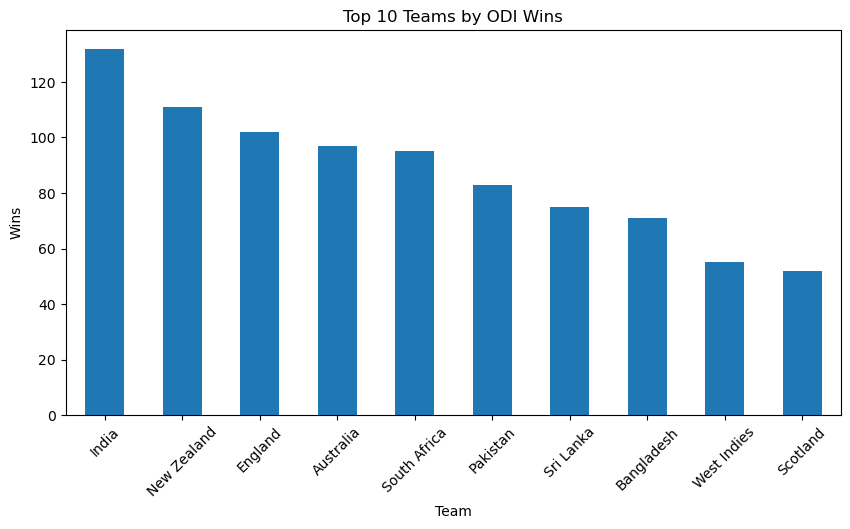

In [36]:
import matplotlib.pyplot as plt

top_winners = df["winner"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_winners.plot(kind="bar")

plt.title("Top 10 Teams by ODI Wins")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.show()

In [32]:
#Most Frequent Teams


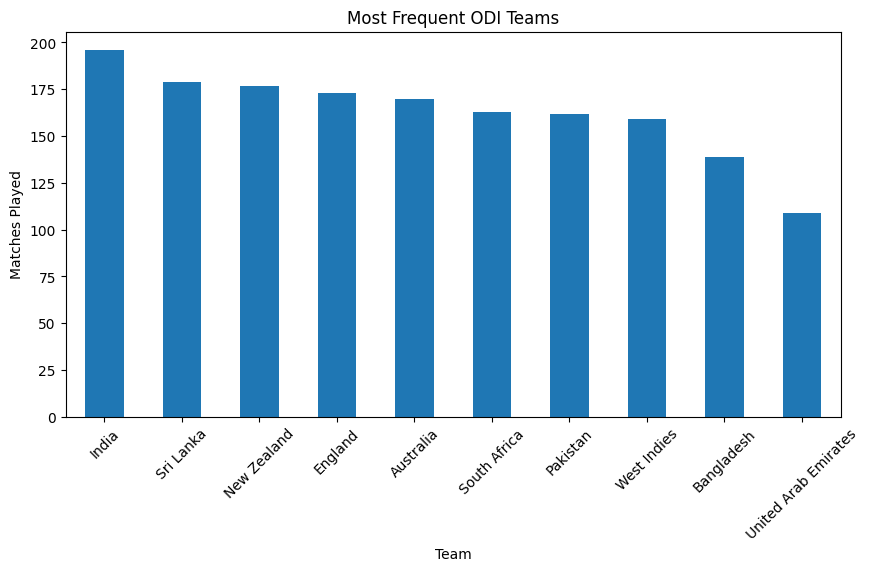

In [33]:
top_teams = team_counts.value_counts().head(10)

plt.figure(figsize=(10,5))
top_teams.plot(kind="bar")

plt.title("Most Frequent ODI Teams")
plt.xlabel("Team")
plt.ylabel("Matches Played")

plt.xticks(rotation=45)

plt.show()

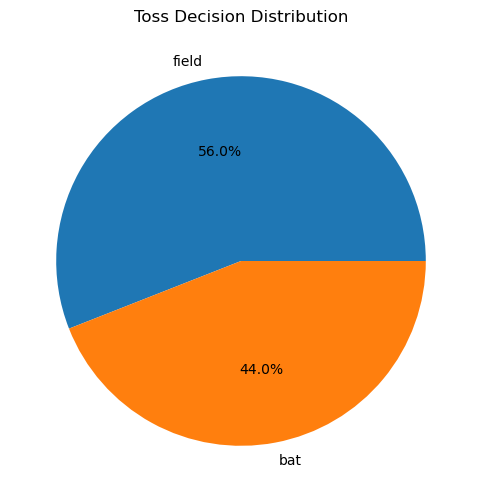

In [37]:
#Toss Decision
df["toss_decision"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Toss Decision Distribution")

plt.ylabel("")

plt.show()

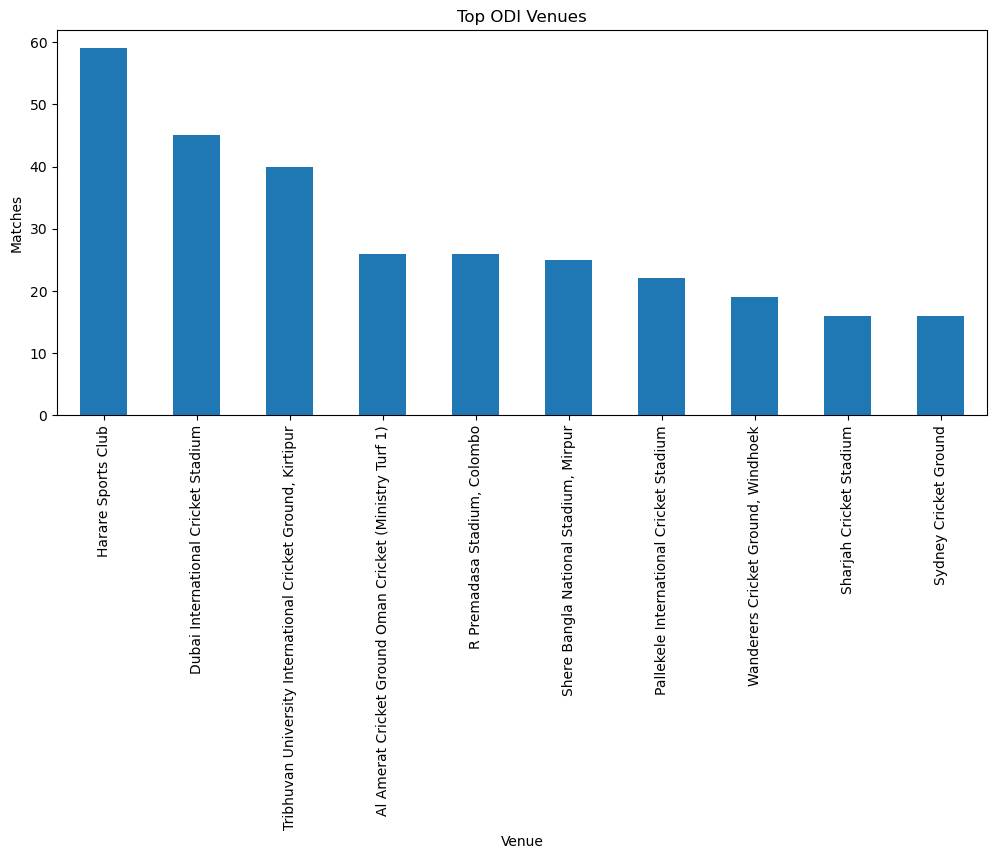

In [38]:
#Top Venues
top_venues = df["venue"].value_counts().head(10)

plt.figure(figsize=(12,5))
top_venues.plot(kind="bar")

plt.title("Top ODI Venues")
plt.xlabel("Venue")
plt.ylabel("Matches")

plt.xticks(rotation=90)

plt.show()

In [39]:
df["year"] = df["date"].dt.year

year_counts = df["year"].value_counts().sort_index()

print(year_counts)

year
2015    123
2016     78
2017    101
2018    101
2019    123
2020     42
2021     60
2022    141
2023    187
2024     84
2025    104
2026     30
Name: count, dtype: int64


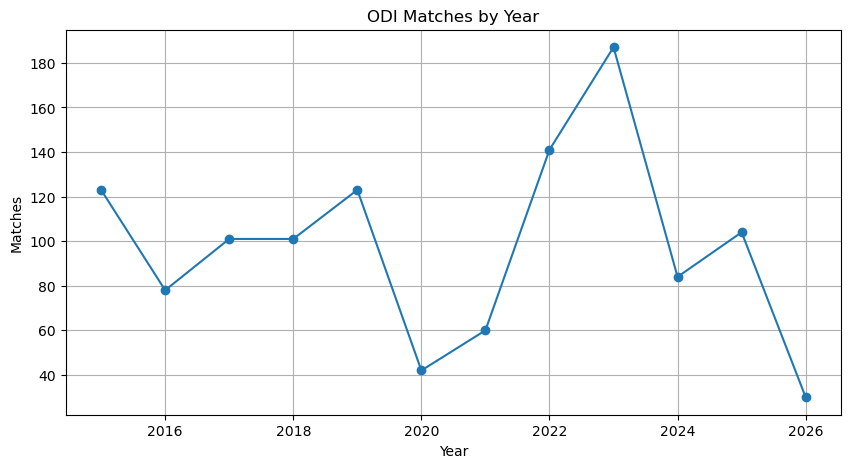

In [40]:
#ODI Trend by Year
plt.figure(figsize=(10,5))

year_counts.plot(kind="line", marker="o")

plt.title("ODI Matches by Year")
plt.xlabel("Year")
plt.ylabel("Matches")

plt.grid(True)

plt.show()

In [41]:
#feature engineering
city_country = {
    "Mumbai": "India",
    "Delhi": "India",
    "Chennai": "India",

    "Sydney": "Australia",
    "Melbourne": "Australia",
    "Brisbane": "Australia",
    "Perth": "Australia",
    "Adelaide": "Australia",
    "Hobart": "Australia",

    "Christchurch": "New Zealand",
    "Hamilton": "New Zealand",
    "Wellington": "New Zealand",
    "Auckland": "New Zealand",
    "Dunedin": "New Zealand",
    "Napier": "New Zealand",

    "London": "England",
    "Manchester": "England",
    "Leeds": "England",

    "Durban": "South Africa",
    "Johannesburg": "South Africa",
    "Cape Town": "South Africa",
    "Centurion": "South Africa",

    "Lahore": "Pakistan",
    "Karachi": "Pakistan",

    "Colombo": "Sri Lanka",

    "Dhaka": "Bangladesh",

    "Dubai": "UAE",
    "Sharjah": "UAE"
}

In [42]:
venue_country = {

    # ---------------- AUSTRALIA ----------------
    "Sydney Cricket Ground": "Australia",
    "Melbourne Cricket Ground": "Australia",
    "Adelaide Oval": "Australia",
    "Bellerive Oval": "Australia",
    "Brisbane Cricket Ground, Woolloongabba": "Australia",
    "Perth Stadium": "Australia",
    "W.A.C.A. Ground": "Australia",
    "Manuka Oval": "Australia",
    "Docklands Stadium": "Australia",

    # ---------------- NEW ZEALAND ----------------
    "Hagley Oval": "New Zealand",
    "Seddon Park": "New Zealand",
    "University Oval": "New Zealand",
    "Westpac Stadium": "New Zealand",
    "McLean Park": "New Zealand",
    "Eden Park": "New Zealand",
    "Saxton Oval": "New Zealand",
    "Bay Oval": "New Zealand",
    "Basin Reserve": "New Zealand",

    # ---------------- INDIA ----------------
    "Wankhede Stadium": "India",
    "Eden Gardens": "India",
    "MA Chidambaram Stadium": "India",
    "M Chinnaswamy Stadium": "India",
    "Arun Jaitley Stadium": "India",
    "Narendra Modi Stadium": "India",
    "Rajiv Gandhi International Stadium": "India",
    "Punjab Cricket Association Stadium": "India",
    "Green Park": "India",

    # ---------------- ENGLAND ----------------
    "Lord's": "England",
    "The Oval": "England",
    "Old Trafford": "England",
    "Headingley": "England",
    "Trent Bridge": "England",
    "Edgbaston": "England",
    "Sophia Gardens": "England",
    "Riverside Ground": "England",

    # ---------------- SOUTH AFRICA ----------------
    "Kingsmead": "South Africa",
    "New Wanderers Stadium": "South Africa",
    "SuperSport Park": "South Africa",
    "Newlands": "South Africa",
    "St George's Park": "South Africa",
    "Mangaung Oval": "South Africa",
    "Buffalo Park": "South Africa",
    "Senwes Park": "South Africa",

    # ---------------- PAKISTAN ----------------
    "Gaddafi Stadium": "Pakistan",
    "National Stadium": "Pakistan",
    "Rawalpindi Cricket Stadium": "Pakistan",
    "Multan Cricket Stadium": "Pakistan",

    # ---------------- SRI LANKA ----------------
    "R Premadasa Stadium": "Sri Lanka",
    "Pallekele International Cricket Stadium": "Sri Lanka",
    "Galle International Stadium": "Sri Lanka",
    "Sinhalese Sports Club Ground": "Sri Lanka",

    # ---------------- BANGLADESH ----------------
    "Shere Bangla National Stadium": "Bangladesh",
    "Zahur Ahmed Chowdhury Stadium": "Bangladesh",

    # ---------------- WEST INDIES ----------------
    "Kensington Oval": "West Indies",
    "Sabina Park": "West Indies",
    "Queen's Park Oval": "West Indies",

    # ---------------- UAE / NEUTRAL ----------------
    "Dubai International Cricket Stadium": "UAE",
    "Sharjah Cricket Stadium": "UAE",
    "Sheikh Zayed Stadium": "UAE"
}

In [43]:
def get_home_team(row):

    # First try city
    country = city_country.get(row["city"])

    # If city fails, try venue
    if country is None:
        country = venue_country.get(row["venue"])

    # Match with teams
    if country == row["team1"]:
        return row["team1"]

    elif country == row["team2"]:
        return row["team2"]

    else:
        return "Neutral"

In [44]:
df.head(50)

,date,team1,team2,city,venue,toss_winner,toss_decision,winner,year
2386,2015-01-11,New Zealand,Sri Lanka,Christchurch,Hagley Oval,Sri Lanka,bat,New Zealand,2015
2433,2015-01-12,Ireland,Scotland,Unknown,Dubai International Cricket Stadium,Ireland,field,Ireland,2015
2387,2015-01-15,New Zealand,Sri Lanka,Hamilton,Seddon Park,New Zealand,bat,Sri Lanka,2015
2333,2015-01-16,South Africa,West Indies,Durban,Kingsmead,South Africa,bat,South Africa,2015
2408,2015-01-16,Australia,England,Unknown,Sydney Cricket Ground,England,bat,Australia,2015
2334,2015-01-18,South Africa,West Indies,Johannesburg,New Wanderers Stadium,West Indies,field,South Africa,2015
2407,2015-01-18,Australia,India,Unknown,Melbourne Cricket Ground,India,bat,Australia,2015
2389,2015-01-20,New Zealand,Sri Lanka,Nelson,Saxton Oval,Sri Lanka,bat,New Zealand,2015
2409,2015-01-20,England,India,Brisbane,"Brisbane Cricket Ground, Woolloongabba",India,bat,England,2015
2335,2015-01-21,South Africa,West Indies,East London,Buffalo Park,West Indies,bat,South Africa,2015


In [45]:
def get_home_team(row):

    # Step 1 → Try city mapping
    country = city_country.get(row["city"])

    # Step 2 → If city not found, use venue matching
    if country is None:

        for venue_key, venue_country_name in venue_country.items():

            if venue_key in row["venue"]:
                country = venue_country_name
                break

    # Step 3 → Match country with teams
    if country == row["team1"]:
        return row["team1"]

    elif country == row["team2"]:
        return row["team2"]

    else:
        return "Neutral"

In [46]:
df["home_team"] = df.apply(get_home_team, axis=1)

In [47]:
df.head(50)

,date,team1,team2,city,venue,toss_winner,toss_decision,winner,year,home_team
2386,2015-01-11,New Zealand,Sri Lanka,Christchurch,Hagley Oval,Sri Lanka,bat,New Zealand,2015,New Zealand
2433,2015-01-12,Ireland,Scotland,Unknown,Dubai International Cricket Stadium,Ireland,field,Ireland,2015,Neutral
2387,2015-01-15,New Zealand,Sri Lanka,Hamilton,Seddon Park,New Zealand,bat,Sri Lanka,2015,New Zealand
2333,2015-01-16,South Africa,West Indies,Durban,Kingsmead,South Africa,bat,South Africa,2015,South Africa
2408,2015-01-16,Australia,England,Unknown,Sydney Cricket Ground,England,bat,Australia,2015,Australia
2334,2015-01-18,South Africa,West Indies,Johannesburg,New Wanderers Stadium,West Indies,field,South Africa,2015,South Africa
2407,2015-01-18,Australia,India,Unknown,Melbourne Cricket Ground,India,bat,Australia,2015,Australia
2389,2015-01-20,New Zealand,Sri Lanka,Nelson,Saxton Oval,Sri Lanka,bat,New Zealand,2015,New Zealand
2409,2015-01-20,England,India,Brisbane,"Brisbane Cricket Ground, Woolloongabba",India,bat,England,2015,Neutral
2335,2015-01-21,South Africa,West Indies,East London,Buffalo Park,West Indies,bat,South Africa,2015,South Africa


In [48]:
# Sort by date
df = df.sort_values("date")
df = df.reset_index(drop=True)

# Empty lists
team1_form = []
team2_form = []

# Loop through matches
for index, row in df.iterrows():

    current_date = row["date"]

    team1 = row["team1"]
    team2 = row["team2"]

    # Only previous matches
    past_matches = df[df["date"] < current_date]

    # Team1 previous 5 matches
    team1_past = past_matches[
        (past_matches["team1"] == team1) |
        (past_matches["team2"] == team1)
    ].tail(5)

    # Team2 previous 5 matches
    team2_past = past_matches[
        (past_matches["team1"] == team2) |
        (past_matches["team2"] == team2)
    ].tail(5)

    # Count wins
    team1_wins = (team1_past["winner"] == team1).sum()
    team2_wins = (team2_past["winner"] == team2).sum()

    # Save into lists
    team1_form.append(team1_wins)
    team2_form.append(team2_wins)

# Add columns
df["team1_recent_form"] = team1_form
df["team2_recent_form"] = team2_form

In [49]:
df.head(50)

,date,team1,team2,city,venue,toss_winner,toss_decision,winner,year,home_team,team1_recent_form,team2_recent_form
0,2015-01-11,New Zealand,Sri Lanka,Christchurch,Hagley Oval,Sri Lanka,bat,New Zealand,2015,New Zealand,0,0
1,2015-01-12,Ireland,Scotland,Unknown,Dubai International Cricket Stadium,Ireland,field,Ireland,2015,Neutral,0,0
2,2015-01-15,New Zealand,Sri Lanka,Hamilton,Seddon Park,New Zealand,bat,Sri Lanka,2015,New Zealand,1,0
3,2015-01-16,South Africa,West Indies,Durban,Kingsmead,South Africa,bat,South Africa,2015,South Africa,0,0
4,2015-01-16,Australia,England,Unknown,Sydney Cricket Ground,England,bat,Australia,2015,Australia,0,0
5,2015-01-18,South Africa,West Indies,Johannesburg,New Wanderers Stadium,West Indies,field,South Africa,2015,South Africa,1,0
6,2015-01-18,Australia,India,Unknown,Melbourne Cricket Ground,India,bat,Australia,2015,Australia,1,0
7,2015-01-20,England,India,Brisbane,"Brisbane Cricket Ground, Woolloongabba",India,bat,England,2015,Neutral,0,0
8,2015-01-20,New Zealand,Sri Lanka,Nelson,Saxton Oval,Sri Lanka,bat,New Zealand,2015,New Zealand,1,1
9,2015-01-21,South Africa,West Indies,East London,Buffalo Park,West Indies,bat,South Africa,2015,South Africa,2,0


In [50]:
team1_h2h = []
team2_h2h = []

for index, row in df.iterrows():

    current_date = row["date"]

    team1 = row["team1"]
    team2 = row["team2"]

    # Previous matches between these two teams
    h2h_matches = df[
        (
            ((df["team1"] == team1) & (df["team2"] == team2)) |
            ((df["team1"] == team2) & (df["team2"] == team1))
        ) &
        (df["date"] < current_date)
    ]

    # Wins count
    team1_wins = (h2h_matches["winner"] == team1).sum()
    team2_wins = (h2h_matches["winner"] == team2).sum()

    # Save
    team1_h2h.append(team1_wins)
    team2_h2h.append(team2_wins)

# Add columns
df["team1_h2h_wins"] = team1_h2h
df["team2_h2h_wins"] = team2_h2h

In [51]:
df[[
    "team1",
    "team2",
    "team1_h2h_wins",
    "team2_h2h_wins"
]].head(20)

,team1,team2,team1_h2h_wins,team2_h2h_wins
0,New Zealand,Sri Lanka,0,0
1,Ireland,Scotland,0,0
2,New Zealand,Sri Lanka,1,0
3,South Africa,West Indies,0,0
4,Australia,England,0,0
5,South Africa,West Indies,1,0
6,Australia,India,0,0
7,England,India,0,0
8,New Zealand,Sri Lanka,1,1
9,South Africa,West Indies,2,0


In [52]:
df["toss_match_win"] = (
    df["toss_winner"] == df["winner"]
).astype(int)

In [53]:
df.head(50)

,date,team1,team2,city,venue,toss_winner,toss_decision,winner,year,home_team,team1_recent_form,team2_recent_form,team1_h2h_wins,team2_h2h_wins,toss_match_win
0,2015-01-11,New Zealand,Sri Lanka,Christchurch,Hagley Oval,Sri Lanka,bat,New Zealand,2015,New Zealand,0,0,0,0,0
1,2015-01-12,Ireland,Scotland,Unknown,Dubai International Cricket Stadium,Ireland,field,Ireland,2015,Neutral,0,0,0,0,1
2,2015-01-15,New Zealand,Sri Lanka,Hamilton,Seddon Park,New Zealand,bat,Sri Lanka,2015,New Zealand,1,0,1,0,0
3,2015-01-16,South Africa,West Indies,Durban,Kingsmead,South Africa,bat,South Africa,2015,South Africa,0,0,0,0,1
4,2015-01-16,Australia,England,Unknown,Sydney Cricket Ground,England,bat,Australia,2015,Australia,0,0,0,0,0
5,2015-01-18,South Africa,West Indies,Johannesburg,New Wanderers Stadium,West Indies,field,South Africa,2015,South Africa,1,0,1,0,0
6,2015-01-18,Australia,India,Unknown,Melbourne Cricket Ground,India,bat,Australia,2015,Australia,1,0,0,0,0
7,2015-01-20,England,India,Brisbane,"Brisbane Cricket Ground, Woolloongabba",India,bat,England,2015,Neutral,0,0,0,0,0
8,2015-01-20,New Zealand,Sri Lanka,Nelson,Saxton Oval,Sri Lanka,bat,New Zealand,2015,New Zealand,1,1,1,1,0
9,2015-01-21,South Africa,West Indies,East London,Buffalo Park,West Indies,bat,South Africa,2015,South Africa,2,0,2,0,0


In [54]:
teams = pd.concat([
    df["team1"],
    df["team2"]
]).unique()

In [55]:
team_strength = {}

for team in teams:

    matches_played = df[
        (df["team1"] == team) |
        (df["team2"] == team)
    ]

    total_matches = len(matches_played)

    total_wins = (
        matches_played["winner"] == team
    ).sum()

    win_pct = total_wins / total_matches

    team_strength[team] = round(win_pct, 3)

In [56]:
team_strength

{'New Zealand': np.float64(0.627),
 'Ireland': np.float64(0.402),
 'South Africa': np.float64(0.583),
 'Australia': np.float64(0.571),
 'England': np.float64(0.59),
 'India': np.float64(0.673),
 'United Arab Emirates': np.float64(0.349),
 'Pakistan': np.float64(0.512),
 'West Indies': np.float64(0.346),
 'Bangladesh': np.float64(0.511),
 'Scotland': np.float64(0.571),
 'Zimbabwe': np.float64(0.294),
 'Sri Lanka': np.float64(0.419),
 'Hong Kong': np.float64(0.385),
 'Papua New Guinea': np.float64(0.2),
 'Namibia': np.float64(0.5),
 'Netherlands': np.float64(0.41),
 'Oman': np.float64(0.515),
 'United States of America': np.float64(0.557),
 'Nepal': np.float64(0.519),
 'Canada': np.float64(0.37),
 'Jersey': np.float64(0.25)}

In [57]:
df[[
    "team1_recent_form",
    "team2_recent_form"
]].describe()

,team1_recent_form,team2_recent_form
count,1174.000000,1174.000000
mean,2.501704,2.402896
std,1.396469,1.375225
min,0.000000,0.000000
25%,1.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,3.000000
max,5.000000,5.000000


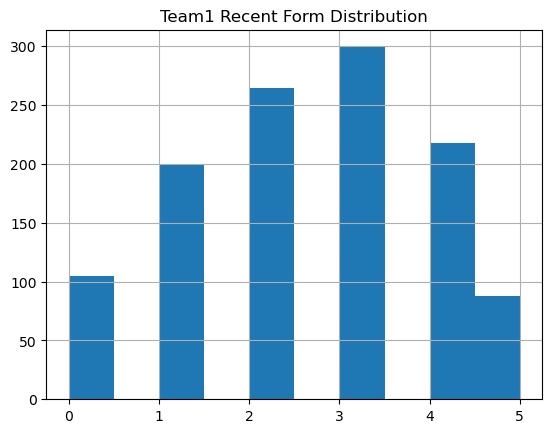

In [58]:
df["team1_recent_form"].hist()

plt.title("Team1 Recent Form Distribution")

plt.show()

In [59]:
df["target"] = (
    df["winner"] == df["team1"]
).astype(int)

In [60]:
df.head()

,date,team1,team2,city,venue,toss_winner,toss_decision,winner,year,home_team,team1_recent_form,team2_recent_form,team1_h2h_wins,team2_h2h_wins,toss_match_win,target
0,2015-01-11,New Zealand,Sri Lanka,Christchurch,Hagley Oval,Sri Lanka,bat,New Zealand,2015,New Zealand,0,0,0,0,0,1
1,2015-01-12,Ireland,Scotland,Unknown,Dubai International Cricket Stadium,Ireland,field,Ireland,2015,Neutral,0,0,0,0,1,1
2,2015-01-15,New Zealand,Sri Lanka,Hamilton,Seddon Park,New Zealand,bat,Sri Lanka,2015,New Zealand,1,0,1,0,0,0
3,2015-01-16,South Africa,West Indies,Durban,Kingsmead,South Africa,bat,South Africa,2015,South Africa,0,0,0,0,1,1
4,2015-01-16,Australia,England,Unknown,Sydney Cricket Ground,England,bat,Australia,2015,Australia,0,0,0,0,0,1


In [61]:
team_strength = {}

teams = pd.concat([
    df["team1"],
    df["team2"]
]).unique()

In [62]:
df.head()

,date,team1,team2,city,venue,toss_winner,toss_decision,winner,year,home_team,team1_recent_form,team2_recent_form,team1_h2h_wins,team2_h2h_wins,toss_match_win,target
0,2015-01-11,New Zealand,Sri Lanka,Christchurch,Hagley Oval,Sri Lanka,bat,New Zealand,2015,New Zealand,0,0,0,0,0,1
1,2015-01-12,Ireland,Scotland,Unknown,Dubai International Cricket Stadium,Ireland,field,Ireland,2015,Neutral,0,0,0,0,1,1
2,2015-01-15,New Zealand,Sri Lanka,Hamilton,Seddon Park,New Zealand,bat,Sri Lanka,2015,New Zealand,1,0,1,0,0,0
3,2015-01-16,South Africa,West Indies,Durban,Kingsmead,South Africa,bat,South Africa,2015,South Africa,0,0,0,0,1,1
4,2015-01-16,Australia,England,Unknown,Sydney Cricket Ground,England,bat,Australia,2015,Australia,0,0,0,0,0,1


In [63]:
for team in teams:

    matches = df[
        (df["team1"] == team) |
        (df["team2"] == team)
    ]

    wins = (matches["winner"] == team).sum()

    strength = wins / len(matches)

    team_strength[team] = strength

In [64]:
df["team1_strength"] = df["team1"].map(team_strength)

df["team2_strength"] = df["team2"].map(team_strength)

In [65]:
df.head(50)

,date,team1,team2,city,venue,toss_winner,toss_decision,winner,year,home_team,team1_recent_form,team2_recent_form,team1_h2h_wins,team2_h2h_wins,toss_match_win,target,team1_strength,team2_strength
0,2015-01-11,New Zealand,Sri Lanka,Christchurch,Hagley Oval,Sri Lanka,bat,New Zealand,2015,New Zealand,0,0,0,0,0,1,0.627119,0.418994
1,2015-01-12,Ireland,Scotland,Unknown,Dubai International Cricket Stadium,Ireland,field,Ireland,2015,Neutral,0,0,0,0,1,1,0.402439,0.571429
2,2015-01-15,New Zealand,Sri Lanka,Hamilton,Seddon Park,New Zealand,bat,Sri Lanka,2015,New Zealand,1,0,1,0,0,0,0.627119,0.418994
3,2015-01-16,South Africa,West Indies,Durban,Kingsmead,South Africa,bat,South Africa,2015,South Africa,0,0,0,0,1,1,0.582822,0.345912
4,2015-01-16,Australia,England,Unknown,Sydney Cricket Ground,England,bat,Australia,2015,Australia,0,0,0,0,0,1,0.570588,0.589595
5,2015-01-18,South Africa,West Indies,Johannesburg,New Wanderers Stadium,West Indies,field,South Africa,2015,South Africa,1,0,1,0,0,1,0.582822,0.345912
6,2015-01-18,Australia,India,Unknown,Melbourne Cricket Ground,India,bat,Australia,2015,Australia,1,0,0,0,0,1,0.570588,0.673469
7,2015-01-20,England,India,Brisbane,"Brisbane Cricket Ground, Woolloongabba",India,bat,England,2015,Neutral,0,0,0,0,0,1,0.589595,0.673469
8,2015-01-20,New Zealand,Sri Lanka,Nelson,Saxton Oval,Sri Lanka,bat,New Zealand,2015,New Zealand,1,1,1,1,0,1,0.627119,0.418994
9,2015-01-21,South Africa,West Indies,East London,Buffalo Park,West Indies,bat,South Africa,2015,South Africa,2,0,2,0,0,1,0.582822,0.345912


In [66]:
numeric_df = df[[
    "team1_recent_form",
    "team2_recent_form",
    "team1_h2h_wins",
    "team2_h2h_wins",
    "team1_strength",
    "team2_strength",
    "target"
]]

In [67]:
corr = numeric_df.corr()

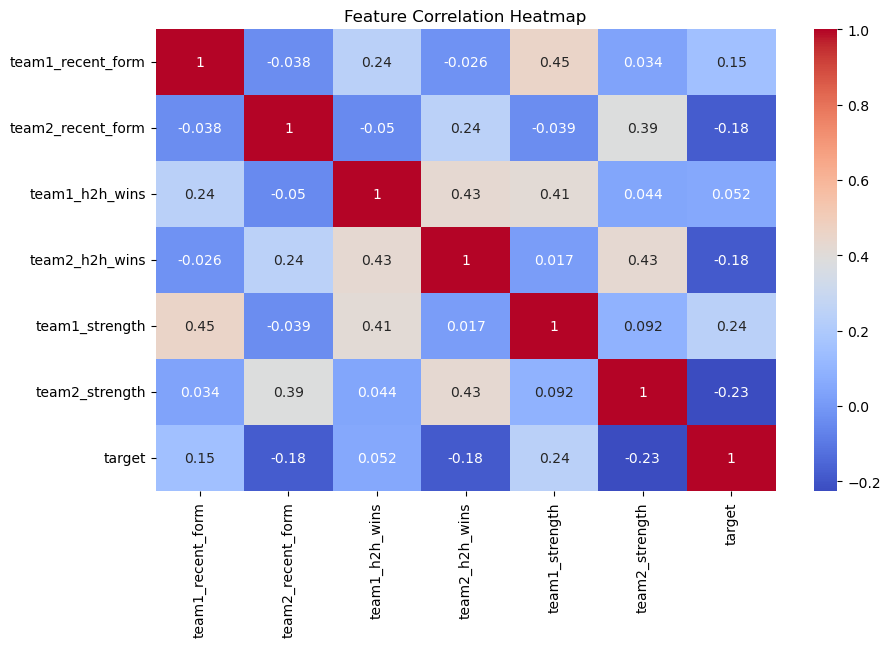

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [69]:
features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "home_team",

    "team1_recent_form",
    "team2_recent_form",

    "team1_h2h_wins",
    "team2_h2h_wins",

    "team1_strength",
    "team2_strength",

    "toss_match_win"
]

In [70]:
X = df[features]

y = df["target"]

In [71]:
X.dtypes

team1                 object
team2                 object
venue                 object
toss_winner           object
toss_decision         object
home_team             object
team1_recent_form      int64
team2_recent_form      int64
team1_h2h_wins         int64
team2_h2h_wins         int64
team1_strength       float64
team2_strength       float64
toss_match_win         int64
dtype: object

In [72]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [73]:
X.shape

(1174, 293)

In [74]:
X.head()

,team1_recent_form,team2_recent_form,team1_h2h_wins,team2_h2h_wins,team1_strength,team2_strength,toss_match_win,team1_Bangladesh,team1_Canada,team1_England,...,toss_decision_field,home_team_Bangladesh,home_team_England,home_team_India,home_team_Neutral,home_team_New Zealand,home_team_Pakistan,home_team_South Africa,home_team_Sri Lanka,home_team_West Indies
0,0,0,0,0,0.627119,0.418994,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,0,0,0,0,0.402439,0.571429,1,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,1,0,1,0,0.627119,0.418994,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,0,0,0.582822,0.345912,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0,0,0,0,0.570588,0.589595,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
model = LogisticRegression(
    max_iter=1000
)

In [78]:
model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [79]:
y_pred = model.predict(
    X_test
)

In [80]:
print(y_pred)

[1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 1
 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1
 1 0 0 1 1 0 1 1 0 0 1 0 0 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 0 0 1 1 1 0 1 1 0
 0 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0
 1 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 0 0 0 1 0 0 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1
 0 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 0 1 1 0 1 1 0 0 0 1 0 0 1 1 0 0
 0 0 1 1 1 1 0 0 1 0 0 0 1]


In [81]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.6638297872340425


In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[61 36]
 [43 95]]


In [83]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
rf_pred = rf_model.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7531914893617021


In [86]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print(rf_cm)

[[ 62  35]
 [ 23 115]]


In [87]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [88]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)


xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [89]:
xgb_pred = xgb_model.predict(X_test)

In [90]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(xgb_accuracy)

0.774468085106383


In [91]:
probs = xgb_model.predict_proba(X_test)

print(probs[:5])

[[0.4880916  0.5119084 ]
 [0.22931844 0.77068156]
 [0.47841007 0.52158993]
 [0.03649235 0.96350765]
 [0.7029203  0.29707965]]


In [92]:
probs = xgb_model.predict_proba(X_test)

print(probs[0])

[0.4880916 0.5119084]


In [93]:
print(xgb_model.predict(X_test[:1]))
print(xgb_model.predict_proba(X_test[:1]))

[1]
[[0.4880916 0.5119084]]


In [94]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [95]:
X.head()

,team1_recent_form,team2_recent_form,team1_h2h_wins,team2_h2h_wins,team1_strength,team2_strength,toss_match_win,team1_Bangladesh,team1_Canada,team1_England,...,toss_decision_field,home_team_Bangladesh,home_team_England,home_team_India,home_team_Neutral,home_team_New Zealand,home_team_Pakistan,home_team_South Africa,home_team_Sri Lanka,home_team_West Indies
0,0,0,0,0,0.627119,0.418994,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,0,0,0,0,0.402439,0.571429,1,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,1,0,1,0,0.627119,0.418994,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,0,0,0.582822,0.345912,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0,0,0,0,0.570588,0.589595,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [96]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [97]:
df.to_csv("odi_final_dataset.csv", index=False)

print("All files saved successfully!")

All files saved successfully!
